# Cosas a limpiar

- **date** -> cambiar a tipo fecha

- **grade** -> ordenar categoricamente

- **attempts** -> quitar el.0 debería ser integer. TIENE 25 NULOS (5%)

- **success** -> deberia ser texto (si o no), para luego generar el dashboard

- **session_duration_min** -> cambiar a horas, minutos y segundos?. Camiar a tipo fecha? TIENE 26 NULOS (5.2%)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv("../data/lizcore_gym_data.csv", parse_dates=["date"])

- Ahora vamos a ordenar los grados 

In [3]:
grade_order = ["5a","5c","6a","6b","6c","7a","7b"]
df["grade"] = pd.Categorical(df["grade"], categories=grade_order, ordered=True)

- Vamos a crear flags de nulos en las columnas "attempts" y "session_duration_min". Asi mantenemos la transparencia sobre imputaciones

In [4]:
df["is_attempts_null"] = df["attempts"].isna()
df["is_duration_null"] = df["session_duration_min"].isna()

# Vamos a buscar outliers:
Antes de decidir cómo imputar nulos, conviene ver si hay valores extremos que puedan distorsionar medias/medianas.

Vamos a Mirar:

**Duración de sesión (session_duration_min)**

- Valores negativos o <30 min (demasiado poco para una sesión representativa).

- Valores >180–200 min (poco realistas en indoor, salvo competiciones).

**Intentos (attempts)**

- Normal es 1–5 intentos; >10 sería sospechoso.

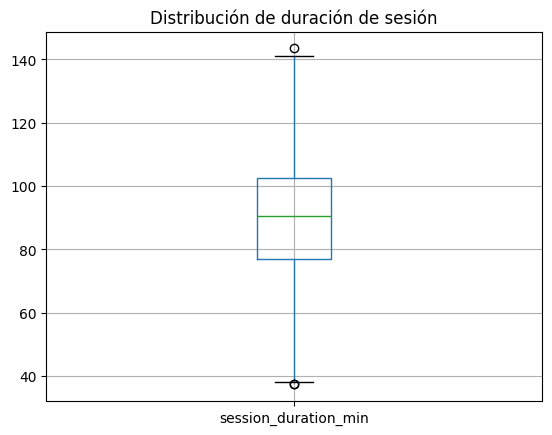

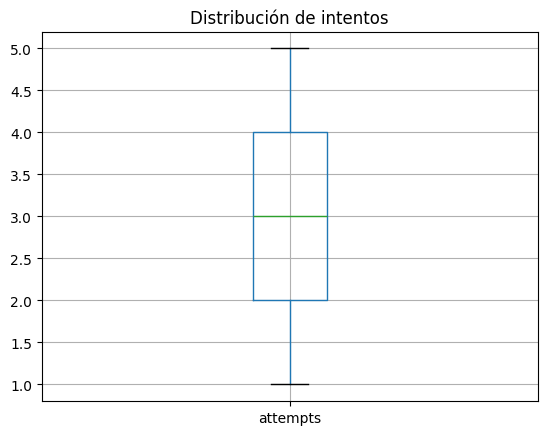

0.01    1.0
0.25    2.0
0.50    3.0
0.75    4.0
0.99    5.0
Name: attempts, dtype: float64

In [5]:
# Boxplots para ver dispersión
import matplotlib.pyplot as plt

plt.figure()
df.boxplot(column="session_duration_min")
plt.title("Distribución de duración de sesión")
plt.show()

plt.figure()
df.boxplot(column="attempts")
plt.title("Distribución de intentos")
plt.show()

# Cuantiles para thresholds
df["session_duration_min"].quantile([0.01, 0.25, 0.5, 0.75, 0.99])
df["attempts"].quantile([0.01, 0.25, 0.5, 0.75, 0.99])


# 1. Distribución de duración de sesión (session_duration_min)

Caja (IQR): la mayoría de sesiones están entre ~75 y 105 min.

Mediana: ~90 min (lo normal en un rocódromo).

Outliers bajos: ~35–40 min (posibles sesiones cortas, quizá error o usuarios que vinieron solo a probar).

Outliers altos: ~140–145 min (poco común, pero plausible si es entrenamiento largo o compes).

**Conclusión**: los outliers no son absurdos (no hay negativos ni >200). Se pueden mantener con un flag de outlier para análisis de calidad, en vez de eliminarlos.

In [6]:
df["is_duration_outlier"] = (df["session_duration_min"] < 40) | (df["session_duration_min"] > 140)


# 2. Distribución de intentos (attempts)

Caja (IQR): entre 2 y 4 intentos.

Mediana: 3 intentos.

Mínimo y máximo: 1 a 5 (justo el rango normal que definimos en la simulación).

Outliers: prácticamente no hay (ninguno fuera del 1–5).

**Conclusión:** no hace falta imputación especial ni tratamiento de outliers para intentos.

# 3. Decisión sobre imputación

Duración: la imputación por mediana por grado sigue siendo la mejor opción → 90 min es representativo.

Intentos: lo mismo, mediana por grado funciona (en grados duros, la mediana de intentos será mayor).

KNN: aquí no añade valor → dataset pequeño, variables poco correlacionadas más allá del grado. No merece la pena la complejidad.

# Imputación ligera por mediana del grado


In [7]:
med_att = df.groupby("grade")["attempts"].median()
med_dur = df.groupby("grade")["session_duration_min"].median()

def fill_by_grade(row, col, medians):
    return medians.get(row["grade"], np.nan) if pd.isna(row[col]) else row[col]

df["attempts_imp"] = df.apply(lambda r: fill_by_grade(r, "attempts", med_att), axis=1)
df["session_duration_imp"] = df.apply(lambda r: fill_by_grade(r, "session_duration_min", med_dur), axis=1)



C:\Users\ebajo\AppData\Local\Temp\ipykernel_4984\1648828604.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  med_att = df.groupby("grade")["attempts"].median()
C:\Users\ebajo\AppData\Local\Temp\ipykernel_4984\1648828604.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  med_dur = df.groupby("grade")["session_duration_min"].median()


**COMPROBAMOS QUE SE HA HECHO BIEN**

In [8]:
# 1) ya no debería haber NaN en las columnas *_imp
print(df["attempts_imp"].isna().sum(), df["session_duration_imp"].isna().sum())

# 2) las originales siguen intactas (transparencia)
df[["attempts","attempts_imp","session_duration_min","session_duration_imp"]].head(10)


0 0


,attempts,attempts_imp,session_duration_min,session_duration_imp
0,3.0,3.0,73.537639,73.537639
1,4.0,4.0,86.716412,86.716412
2,1.0,1.0,99.399965,99.399965
3,3.0,3.0,NaN,88.314811
4,3.0,3.0,110.241357,110.241357
5,1.0,1.0,44.317043,44.317043
6,5.0,5.0,94.786169,94.786169
7,3.0,3.0,118.586485,118.586485
8,5.0,5.0,63.242530,63.242530
9,NaN,3.0,101.031185,101.031185


# CALENDARIO para PowerBI
Añadimos columnas de tiempo útiles para análisis y BI, que facilitan el filtrado, creación de ejes, etc

In [9]:
df["day"] = df["date"].dt.date
df["year"] = df["date"].dt.year
df["month_num"] = df["date"].dt.month
df["month_name"] = df["date"].dt.strftime("%b")
df["week_num"] = df["date"].dt.isocalendar().week.astype(int)
df["weekday_num"] = df["date"].dt.weekday + 1  # Monday=1
df["weekday_name"] = df["date"].dt.strftime("%A")

eliminamos columnas que sobran

In [10]:
df

,date,user_id,route_id,grade,attempts,success,session_duration_min,is_attempts_null,is_duration_null,is_duration_outlier,attempts_imp,session_duration_imp,day,year,month_num,month_name,week_num,weekday_num,weekday_name
0,2025-02-08,7,26,5c,3.0,1,73.537639,False,False,False,3.0,73.537639,2025-02-08,2025,2,Feb,6,6,Saturday
1,2025-02-21,57,19,5c,4.0,0,86.716412,False,False,False,4.0,86.716412,2025-02-21,2025,2,Feb,8,5,Friday
2,2025-01-29,36,19,7a,1.0,0,99.399965,False,False,False,1.0,99.399965,2025-01-29,2025,1,Jan,5,3,Wednesday
3,2025-01-15,45,21,6b,3.0,1,NaN,False,True,False,3.0,88.314811,2025-01-15,2025,1,Jan,3,3,Wednesday
4,2025-02-12,20,5,5a,3.0,0,110.241357,False,False,False,3.0,110.241357,2025-02-12,2025,2,Feb,7,3,Wednesday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,2025-02-19,27,18,6a,2.0,1,105.117099,False,False,False,2.0,105.117099,2025-02-19,2025,2,Feb,8,3,Wednesday
496,2025-01-25,93,1,6c,1.0,1,88.031220,False,False,False,1.0,88.031220,2025-01-25,2025,1,Jan,4,6,Saturday
497,2025-01-24,32,14,6c,3.0,0,NaN,False,True,False,3.0,92.995545,2025-01-24,2025,1,Jan,4,5,Friday
498,2025-01-13,50,19,5a,4.0,0,92.765974,False,False,False,4.0,92.765974,2025-01-13,2025,1,Jan,3,1,Monday


# KPIs rápidos para entender el dato

Inspeccionamos señales básicas: uso, éxito, dificultad real

In [11]:
sessions_daily = df.groupby("day").size()

users_daily = df.groupby("day")["user_id"].nunique()

success_global = df["success"].mean()

success_by_grade = df.groupby("grade")["success"].mean()

att_by_grade = df.groupby("grade")["attempts_imp"].mean()

dur_daily = df.groupby("day")["session_duration_imp"].mean()



C:\Users\ebajo\AppData\Local\Temp\ipykernel_4984\2504370862.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  success_by_grade = df.groupby("grade")["success"].mean()
C:\Users\ebajo\AppData\Local\Temp\ipykernel_4984\2504370862.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  att_by_grade = df.groupby("grade")["attempts_imp"].mean()


# Export para Power BI (hechos + date dim + resumen de vías)

Guardamos una tabla de hechos curada, una dimensión fecha, y un resumen de vías ya que BI trabaja mejor si separas hechos/dimensiones; el resumen acelera una página específica.
Construimos una tabla resumen por vía, con número de sesiones, usuarios únicos, tasa de éxito y media de intentos. Esto permite ver qué vías son más populares, cuáles son más duras de lo esperado y cuáles se están quedando frías para rotación.

In [12]:
# Hechos curados
df.to_csv("../data/lizcore_gym_data_clean.csv", index=False)

# Dimensión fecha
date_min, date_max = df["day"].min(), df["day"].max()
date_dim = pd.date_range(date_min, date_max, freq="D").to_frame(index=False, name="date")
date_dim["day"] = date_dim["date"].dt.date
date_dim["year"] = date_dim["date"].dt.year
date_dim["month_num"] = date_dim["date"].dt.month
date_dim["month_name"] = date_dim["date"].dt.strftime("%b")
date_dim["week_num"] = date_dim["date"].dt.isocalendar().week.astype(int)
date_dim["weekday_num"] = date_dim["date"].dt.weekday + 1
date_dim["weekday_name"] = date_dim["date"].dt.strftime("%A")
date_dim.to_csv("../data/date_dim.csv", index=False)

# Resumen vías
route_summary = (
    df.groupby(["route_id","grade"], dropna=False)
      .agg(
          sessions=("route_id","size"),
          users=("user_id","nunique"),
          success_rate=("success","mean"),
          attempts_mean=("attempts_imp","mean"),
      )
      .reset_index()
      .sort_values("sessions", ascending=False)
)
route_summary.to_csv("../data/route_popularity_summary.csv", index=False)


C:\Users\ebajo\AppData\Local\Temp\ipykernel_4984\2085175476.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["route_id","grade"], dropna=False)


Vamos a manipular la columna de session duration min imputada para que los separadores no sean puntos y no de problemas en power query

In [16]:
df.to_csv(
    "../data/lizcore_gym_data_clean.csv",
    index=False,
    sep=";",             # separador de columnas
    decimal=",",         # usa coma como separador decimal
    float_format="%.2f"  # 2 decimales (evita notación científica)
)


In [14]:
df.to_csv(
    "../data/route_popularity_summary.csv",
    index=False,
    sep=";",
    decimal=",",
    float_format="%.2f"
)
